In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

# --------------------------------------------------
# Cost matrices
# --------------------------------------------------
def pairwise_l1_cost(X0, X1):
    return np.abs(X0[:, None, :] - X1[None, :, :]).sum(axis=2)

def pairwise_l2_cost(X0, X1):
    return np.sqrt(((X0[:, None, :] - X1[None, :, :]) ** 2).sum(axis=2))

def pairwise_sym_poisson_cost(X0, X1, eps=1e-8):
    """
    Symmetric Poisson-style deviance / symmetric generalized KL in count space:
        D(x||y) + D(y||x),
    where
        D(x||y) = sum_k [ x_k log((x_k+eps)/(y_k+eps)) - x_k + y_k ].
    """
    A = X0[:, None, :].astype(np.float64)   # [n0,1,2]
    B = X1[None, :, :].astype(np.float64)   # [1,n1,2]

    d_ab = A * np.log((A + eps) / (B + eps)) - A + B
    d_ba = B * np.log((B + eps) / (A + eps)) - B + A
    return (d_ab + d_ba).sum(axis=2)

# --------------------------------------------------
# Hard OT-style pairing via Hungarian assignment
# --------------------------------------------------
def hard_ot_pairing(cost_matrix):
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    return row_ind, col_ind

# --------------------------------------------------
# Plot helper
# --------------------------------------------------
def plot_ot_pairings_1x3(X0_2d, X1_2d, point_size=35, line_alpha=0.35):
    X0_2d = np.asarray(X0_2d, dtype=np.float64)
    X1_2d = np.asarray(X1_2d, dtype=np.float64)

    costs = {
        "L1": pairwise_l1_cost(X0_2d, X1_2d),
        "L2": pairwise_l2_cost(X0_2d, X1_2d),
        "Symmetric Poisson": pairwise_sym_poisson_cost(X0_2d, X1_2d),
    }

    all_x = np.concatenate([X0_2d[:, 0], X1_2d[:, 0]])
    all_y = np.concatenate([X0_2d[:, 1], X1_2d[:, 1]])
    xpad = 0.05 * max(1.0, all_x.max() - all_x.min())
    ypad = 0.05 * max(1.0, all_y.max() - all_y.min())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

    for ax, (name, C) in zip(axes, costs.items()):
        rows, cols = hard_ot_pairing(C)

        # lines
        for i, j in zip(rows, cols):
            ax.plot(
                [X0_2d[i, 0], X1_2d[j, 0]],
                [X0_2d[i, 1], X1_2d[j, 1]],
                alpha=line_alpha,
                linewidth=1
            )

        # points
        ax.scatter(X0_2d[:, 0], X0_2d[:, 1], s=point_size, alpha=0.9, label="source")
        ax.scatter(X1_2d[:, 0], X1_2d[:, 1], s=point_size, alpha=0.9, label="target")

        ax.set_title(f"{name}\nmatched cost = {C[rows, cols].sum():.2f}")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_xlim(all_x.min() - xpad, all_x.max() + xpad)
        ax.set_ylim(all_y.min() - ypad, all_y.max() + ypad)
        ax.set_aspect("equal", adjustable="box")

    axes[0].legend(loc="best")
    plt.tight_layout()
    plt.show()


# 1. Hard Assignemnt

In [16]:
rng = np.random.default_rng(7)

def sample_mix_poisson(n, weights, mus):
    z = rng.choice(len(weights), size=n, p=np.array(weights) / np.sum(weights))
    X = np.zeros((n, 2), dtype=int)
    for k in range(len(weights)):
        idx = np.where(z == k)[0]
        if len(idx) > 0:
            X[idx] = rng.poisson(lam=np.array(mus[k]), size=(len(idx), 2))
    return X

X0_2d = sample_mix_poisson(
    100,
    weights=[0.40, 0.35, 0.25],
    mus=[[1, 10], [4, 4], [10, 1]],
)

X1_2d = sample_mix_poisson(
    100,
    weights=[0.35, 0.40, 0.25],
    mus=[[12, 27], [27, 22], [27, 30]],
)

print(X0_2d.shape, X1_2d.shape)

(100, 2) (100, 2)


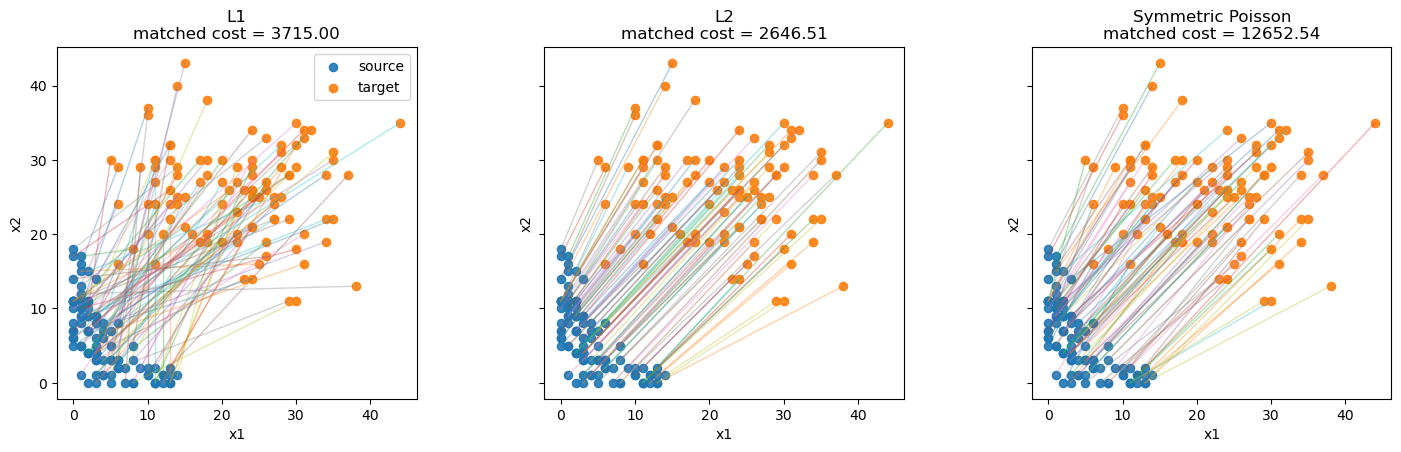

In [17]:
plot_ot_pairings_1x3(X0_2d, X1_2d)

In [18]:
rng = np.random.default_rng(7)

def sample_zip_mix(n, weights, mus, p_zero=0.6):
    z = rng.choice(len(weights), size=n, p=np.array(weights) / np.sum(weights))
    X = np.zeros((n, 2), dtype=int)
    for k in range(len(weights)):
        idx = np.where(z == k)[0]
        if len(idx) == 0:
            continue
        Xk = rng.poisson(lam=np.array(mus[k]), size=(len(idx), 2))
        mask = rng.random((len(idx), 2)) < p_zero
        Xk[mask] = 0
        X[idx] = Xk
    return X

X0_2d = sample_zip_mix(
    100,
    weights=[0.45, 0.35, 0.20],
    mus=[[0.5, 6.0], [2.0, 2.0], [6.0, 0.5]],
    p_zero=0.70,
)

X1_2d = sample_zip_mix(
    100,
    weights=[0.40, 0.35, 0.25],
    mus=[[0.5, 9.0], [3.0, 2.0], [8.0, 0.5]],
    p_zero=0.70,
)

print(X0_2d.shape, X1_2d.shape)
print("X0 zero fraction =", (X0_2d == 0).mean())
print("X1 zero fraction =", (X1_2d == 0).mean())

(100, 2) (100, 2)
X0 zero fraction = 0.79
X1 zero fraction = 0.735


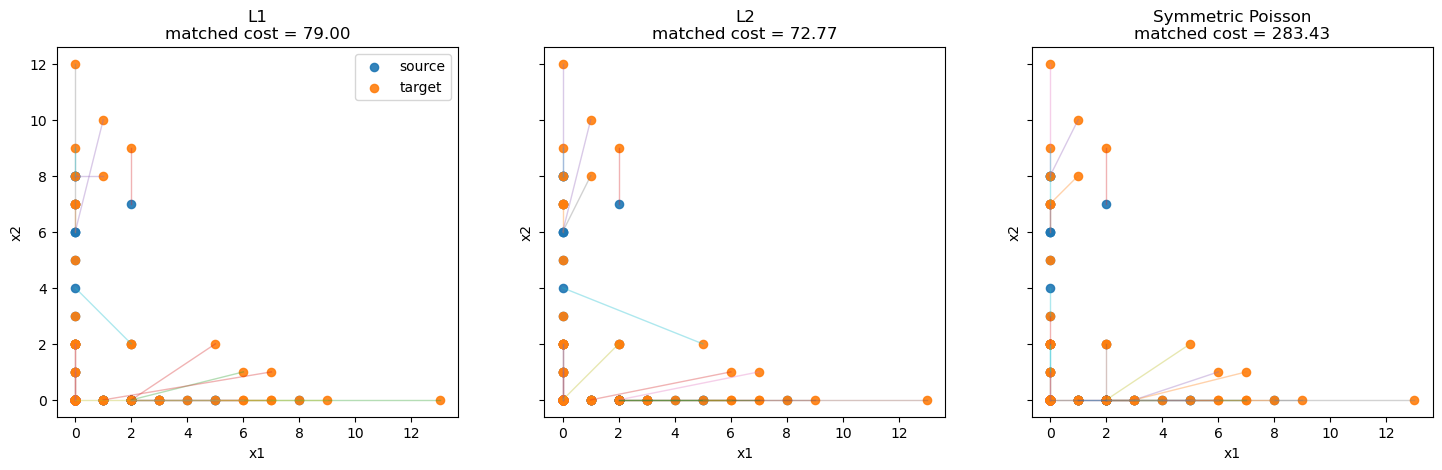

In [19]:
plot_ot_pairings_1x3(X0_2d, X1_2d)

# 2. Soft Assignment

In [21]:
import ot  # POT

def cost_l1(X0, X1):
    return np.abs(X0[:, None, :] - X1[None, :, :]).sum(axis=2)


def cost_l2(X0, X1):
    D = X0[:, None, :] - X1[None, :, :]
    return (D ** 2).sum(axis=2)  # squared L2


def cost_sym_poisson(X0, X1, eps=1e-8):
    A = X0[:, None, :].astype(float)
    B = X1[None, :, :].astype(float)
    d_ab = A * np.log((A + eps) / (B + eps)) - A + B
    d_ba = B * np.log((B + eps) / (A + eps)) - B + A
    return (d_ab + d_ba).sum(axis=2)


def get_soft_plan(X0, X1, kind):
    a = ot.unif(len(X0))
    b = ot.unif(len(X1))

    if kind == "L1":
        M = cost_l1(X0, X1)
    elif kind == "L2":
        M = cost_l2(X0, X1)
    elif kind == "Symmetric Poisson":
        M = cost_sym_poisson(X0, X1)
    else:
        raise ValueError(kind)

    pi = ot.emd(a, b, M)
    return pi, M


def plot_soft_ot_1x3(X0_2d, X1_2d, top_k=80):
    X0_2d = np.asarray(X0_2d, dtype=float)
    X1_2d = np.asarray(X1_2d, dtype=float)

    names = ["L1", "L2", "Symmetric Poisson"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

    all_x = np.r_[X0_2d[:, 0], X1_2d[:, 0]]
    all_y = np.r_[X0_2d[:, 1], X1_2d[:, 1]]
    xpad = 0.05 * max(1.0, all_x.max() - all_x.min())
    ypad = 0.05 * max(1.0, all_y.max() - all_y.min())

    for ax, name in zip(axes, names):
        pi, M = get_soft_plan(X0_2d, X1_2d, name)

        flat = pi.ravel()
        keep = np.argsort(flat)[::-1]
        keep = keep[flat[keep] > 0][:top_k]

        mmax = flat[keep].max() if len(keep) > 0 else 1.0

        for idx in keep:
            i, j = np.unravel_index(idx, pi.shape)
            mass = pi[i, j]
            alpha = 0.08 + 0.92 * (mass / mmax)
            lw = 0.4 + 3.0 * (mass / mmax)
            ax.plot(
                [X0_2d[i, 0], X1_2d[j, 0]],
                [X0_2d[i, 1], X1_2d[j, 1]],
                alpha=alpha,
                linewidth=lw,
            )

        ax.scatter(X0_2d[:, 0], X0_2d[:, 1], s=25, alpha=0.9, label="source")
        ax.scatter(X1_2d[:, 0], X1_2d[:, 1], s=25, alpha=0.9, label="target")
        ax.set_title(f"{name}\nOT cost = {(pi * M).sum():.2f}")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_xlim(all_x.min() - xpad, all_x.max() + xpad)
        ax.set_ylim(all_y.min() - ypad, all_y.max() + ypad)
        ax.set_aspect("equal", adjustable="box")

    axes[0].legend(loc="best")
    plt.tight_layout()
    plt.show()


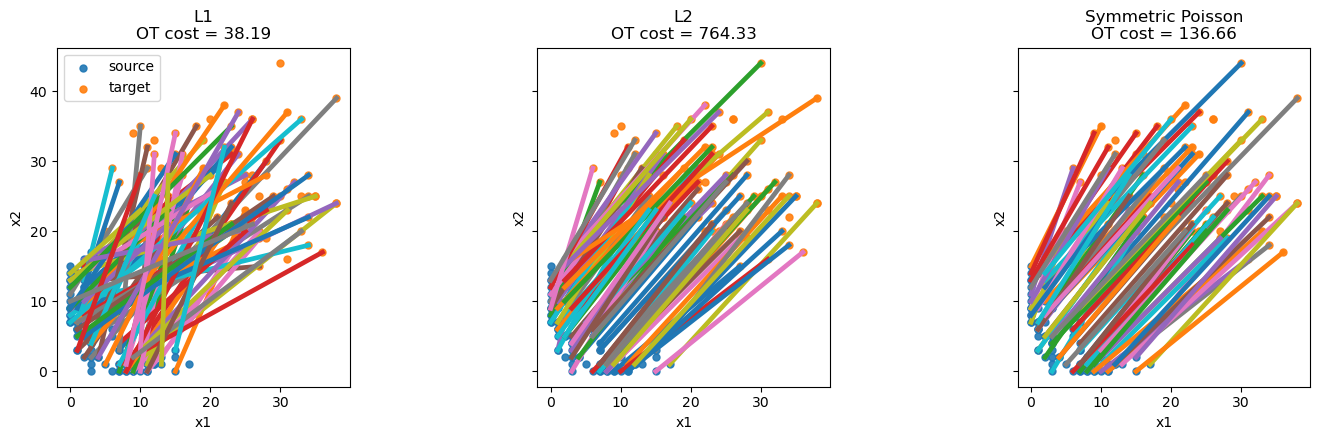

In [22]:
X0_2d = sample_mix_poisson(
    100,
    weights=[0.40, 0.35, 0.25],
    mus=[[1, 10], [4, 4], [10, 1]],
)

X1_2d = sample_mix_poisson(
    100,
    weights=[0.35, 0.40, 0.25],
    mus=[[12, 27], [27, 22], [27, 30]],
)

plot_soft_ot_1x3(X0_2d, X1_2d, top_k=80)

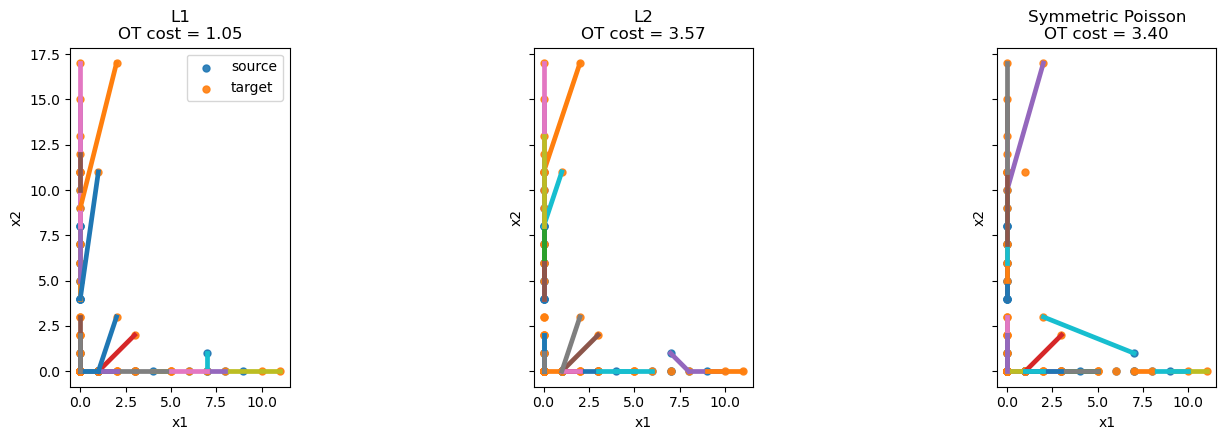

In [23]:
X0_2d = sample_zip_mix(
    100,
    weights=[0.45, 0.35, 0.20],
    mus=[[0.5, 6.0], [2.0, 2.0], [6.0, 0.5]],
    p_zero=0.70,
)

X1_2d = sample_zip_mix(
    100,
    weights=[0.40, 0.35, 0.25],
    mus=[[0.5, 9.0], [3.0, 2.0], [8.0, 0.5]],
    p_zero=0.70,
)

plot_soft_ot_1x3(X0_2d, X1_2d, top_k=80)